# Metallicity Gradient of the Disk with APOGEE Results

In this example, we will explore how to combine various [`astra`](https://www.sdss.org/dr19/mwm/astra/) data products to examine the metallicity gradient in the Milky Way disk. The below example is best run on [SciServer](https://www.sciserver.org), where the instructions in this repository describe how to setup an account, and container with the appropriate environment.

## Package Setup

Below we will import the standard Python and astronomy related packages to run this tutorial.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.table import Table, join
from astropy.coordinates import SkyCoord
import astropy.coordinates as acoo
import astropy.units as u

from scipy.stats import binned_statistic_2d

%matplotlib inline

plt.rcParams.update({'figure.facecolor': 'white',
                      'savefig.facecolor': 'white',
                      'font.size': 24,
                      'xtick.labelsize': 24,
                      'ytick.labelsize': 24,
                      'errorbar.capsize': 2})

For working with SDSS data, we will also include two SDSS-centric packages: [`sdss_semaphore`](https://www.sdss.org/dr19/software/packages/semaphore) and [`sdss_access`](https://www.sdss.org/dr19/software/packages/sdss-access/). `sdss_semaphore` is used to interpret the [SDSS-V Targeting Flags](https://www.sdss.org/dr19/targeting/flags), so we can access targeting information for the various sources. `sdss_access` is a convenient tool for navigating both the local and remote file system paths from the Science Archive Server (SAS). It is especially helpful on SciServer, as the SAS has been copied here directly, meaning `sdss_access` can be used to construct paths and open relevant files.

In [2]:
from sdss_semaphore.targeting import TargetingFlags
import sdss_access

## Loading Files

For this example, we are interested in the results from two data analysis pipelines (DAPs): [ASPCAP](https://sdss.org/dr19/mwm/astra/pipelines-in-astra/aspcap/) and [AstroNNdist](https://sdss.org/dr19/mwm/astra/pipelines-in-astra/astronn/). ASPCAP provides stellar parameters for APOGEE spectra and spectrophotometric distances.

In the below code, we will first setup the path object. This allows us to specify the SDSS data release we are interested in, which in this case is DR19. Second, we will use that object to get the full path to a file we are interested in. In this case it will be the `astra` ASPCAP file, `astraAllStarASPCAP`, where all we need to specify is the `astra` it was run on. Finally, we can open the ASPCAP file. Note that APOGEE data is always stored in the second HDU for the `astra` summary data products.

In [3]:
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
aspcap_file = sdss_path.full('astraAllStarASPCAP', v_astra='0.6.0')
aspcap = Table.read(aspcap_file, hdu=2)

In [4]:
aspcap_file

'/home/idies/workspace/sdss_sas/dr19/spectro/astra/0.6.0/summary/astraAllStarASPCAP-0.6.0.fits.gz'

We can load the AstroNNdist file in a similar manner.

In [5]:
astronn_dist_file = sdss_path.full('astraAllStarAstroNNdist', v_astra='0.6.0')
astronn_dist = Table.read(astronn_dist_file, hdu=2)

## Joining Files

SDSS-V includes a unique targeting identifier, `sdss_id`. This will be the main identifier to join files on. There are a few subtleties to this. `astra` runs things at the "visit" and "star" level. Visits are defined per MJD and stars are the coadds across a survey. Here, we are examining the data at the star level. Additionally, at both levels `astra` evaluates sources per observatory and release. For the latter, this is especially important for APOGEE data as `astra` was run on both DR17 APOGEE I/II data and APOGEE data taken during SDSS-V. These show up as separate entries of a star was observed during both phases.

Below, we will join ASPCAP and AstroNNdist on these three columns to provide the spectrophotometric distances for the ASPCAP targets.

In [6]:
cols_to_use = ['sdss_id', 'telescope', 'release',
               'nn_dist', 'nn_dist_err', 'nn_dist_model_err',
               'nn_parallax', 'nn_parallax_err', 'nn_parallax_model_err',
               'gdr3_parallax_w_zp', 'gdr3_parallax_err', 'gdr3_zeropoint',
               'weighted_parallax', 'weighted_parallax_err',
               'weighted_dist', 'weighted_dist_err',
               'result_flags', 'flag_warn', 'flag_bad']

aspcap_dist = join(aspcap, astronn_dist[cols_to_use],
                   keys=['sdss_id', 'telescope', 'release'],
                   table_names=['aspcap', 'astronn_dist'])

[WARNING]: Cannot merge meta key 'PIPELINE' types <class 'str'> and <class 'str'>, choosing PIPELINE='AstroNNdist' (MergeConflictWarning)
[WARNING]: Cannot merge meta key 'CREATED' types <class 'str'> and <class 'str'>, choosing CREATED='24-10-08 16:20:38' (MergeConflictWarning)
[WARNING]: Cannot merge meta key 'CHECKSUM' types <class 'str'> and <class 'str'>, choosing CHECKSUM='Xh78ag67Rg67Xg67' (MergeConflictWarning)
[WARNING]: Cannot merge meta key 'DATASUM' types <class 'str'> and <class 'str'>, choosing DATASUM='1288531712' (MergeConflictWarning)


# Filtering Targets

SDSS-V is a targeted survey, organized into mappers, programs and cartons. `astra` is specifically run on Milky Way Mapper (MWM) targets. Programs are then the higher level targeting and defining a specific scientific goal. The cartons then fall under are program and consistent of the specific target selections with varying cadences that are designed to accomplish the goals of the program.

Of interest for this tutorial is [Galactic Genesis](https://www.sdss.org/dr19/mwm/programs/gg/), MWM's largest program. It selects red giants above the red clump to ensure coverage of distant giants over a large region of the Galactic disk. With `sdss_semaphore`, we can use the targeting flags to easily select stars from this program.

In [7]:
flags = TargetingFlags(aspcap_dist['sdss5_target_flags'])
gg_inds = flags.in_program("mwm_gg")

np.sum(gg_inds)

193209

In [8]:
gg_catalog = aspcap_dist[gg_inds]

Finally, we will make some cuts based on the quality of the ASPCAP data.

In [9]:
good_gg_inds = (gg_catalog["flag_bad_aspcap"] == 0) & \
               (gg_catalog["spectrum_flags"]==0) & \
               (gg_catalog["snr"] > 40)

## Metallicity Gradient

Now that we have loaded are data, joined the two files and filtered things, we can finally examine the metallicity gradient across the disk. Below we use `astropy` to convert to Galactic coordinates and finally examine the median metallicity across the disk.

In [10]:
c = SkyCoord(gg_catalog['ra']*u.deg,
             gg_catalog['dec']*u.deg,
             distance=gg_catalog['nn_dist']*u.pc)

galcencoo = c.transform_to(acoo.Galactocentric)

gg_catalog["x"] = galcencoo.x.to("kpc").value
gg_catalog["y"] = galcencoo.y.to("kpc").value
gg_catalog["z"] = galcencoo.z.to("kpc").value
gg_catalog["absz"] = np.abs(gg_catalog["z"])
gg_catalog["R"] = np.sqrt(gg_catalog["x"]**2 + gg_catalog["y"]**2)

[WARNING]: All-NaN slice encountered (RuntimeWarning)


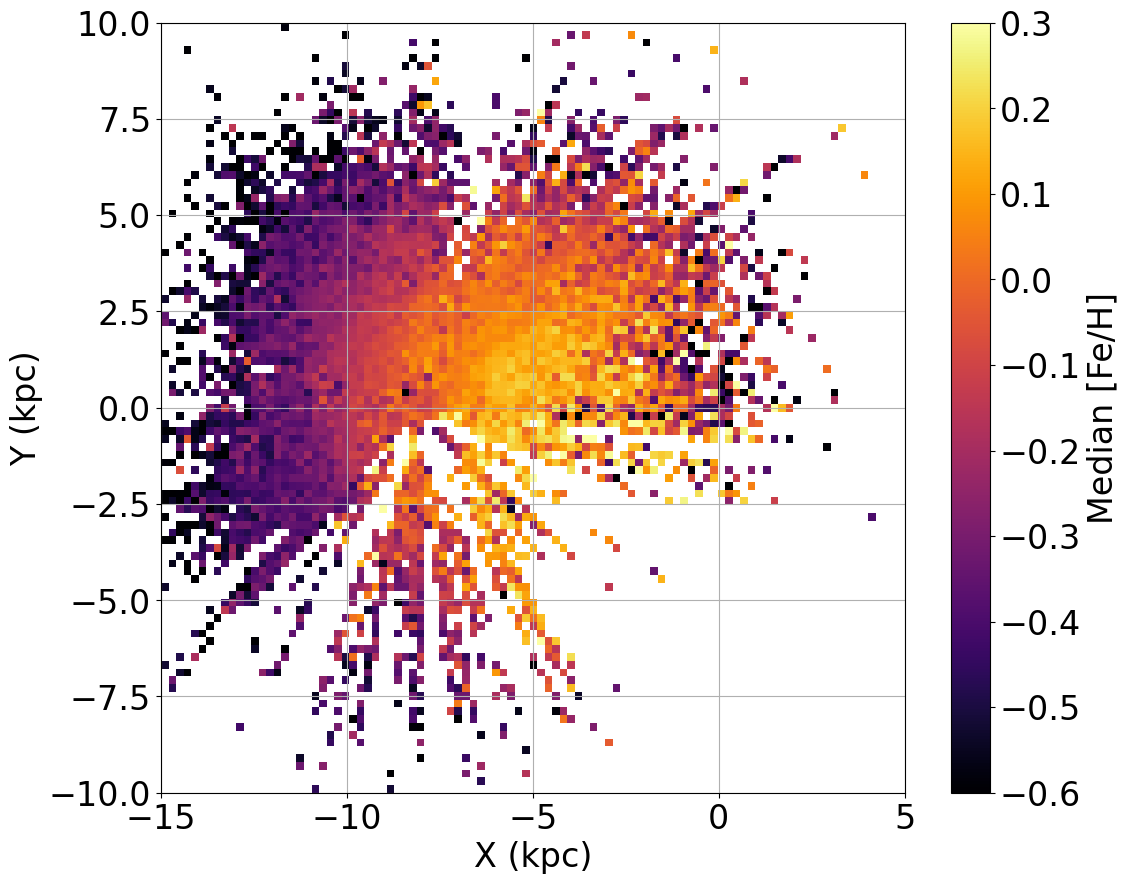

In [11]:
xbin = np.linspace(-15, 5, 100)
ybin = np.linspace(-10, 10, 100)

zcut = abs(gg_catalog["z"]) < 0.25

Nxy, _, _, _ = binned_statistic_2d(gg_catalog["x"][good_gg_inds & zcut],
                                   gg_catalog["y"][good_gg_inds & zcut],
                                   gg_catalog["fe_h"][good_gg_inds & zcut],
                                   np.nanmedian,
                                   bins=[xbin, ybin])

plt.figure(figsize=(12, 10))
res = plt.imshow(Nxy.T, origin='lower', aspect='auto',
                 extent=[xbin.min(), xbin.max(), ybin.min(), ybin.max()],
                 cmap='inferno', vmin=-0.6, vmax=0.3)
plt.colorbar(res, label='Median [Fe/H]')
plt.xlabel('X (kpc)')
plt.ylabel('Y (kpc)')
plt.grid()
plt.show()


We see that there is a very clear metallicity gradient where stars near the Galactic center are metal-rich and the outer Galaxy more metal-poor.

Now that we have the data loaded, see what other trends you can observe! ASPCAP includes stellar parameters and detailed abundances for a number of elements!

## Aside on Spectra...

It is also quite easy to examine specific spectra with `astra`. All that is needed is the `sdss_id` and telescope for the observation. Additionally, for DAPs like ASPCAP, you can examine the model results for that spectrum as well.

Below, with a few lines of code, we will load the observed and model spectra for a source. Then, we will plot these spectra.

In [12]:
# select a source

ev_star = np.where((aspcap['teff'] > 5500) & (aspcap['fe_h'] > 0.) & (~aspcap['flag_bad']) & (aspcap['snr'] > 100))

sdss_id = aspcap["sdss_id"][ev_star[0][0]]
telescope = gg_catalog["telescope"][ev_star[0][0]]

# load the model spectrum
aspcapStar_filename = sdss_path.full('astraStarASPCAP',
                                     v_astra='0.6.0',
                                     component='',
                                     sdss_id=sdss_id)
if telescope == 'apo25m':
    hdu = 3
else:
    hdu = 4
aspcapStar = Table.read(aspcapStar_filename, hdu=hdu)

# load the observed spectrum
mwmStar_filename = sdss_path.full('mwmStar',
                                  v_astra='0.6.0',
                                  component='',
                                  sdss_id=sdss_id)
mwmStar = Table.read(mwmStar_filename, hdu=hdu)

[WARNING]: divide by zero encountered in power (RuntimeWarning)


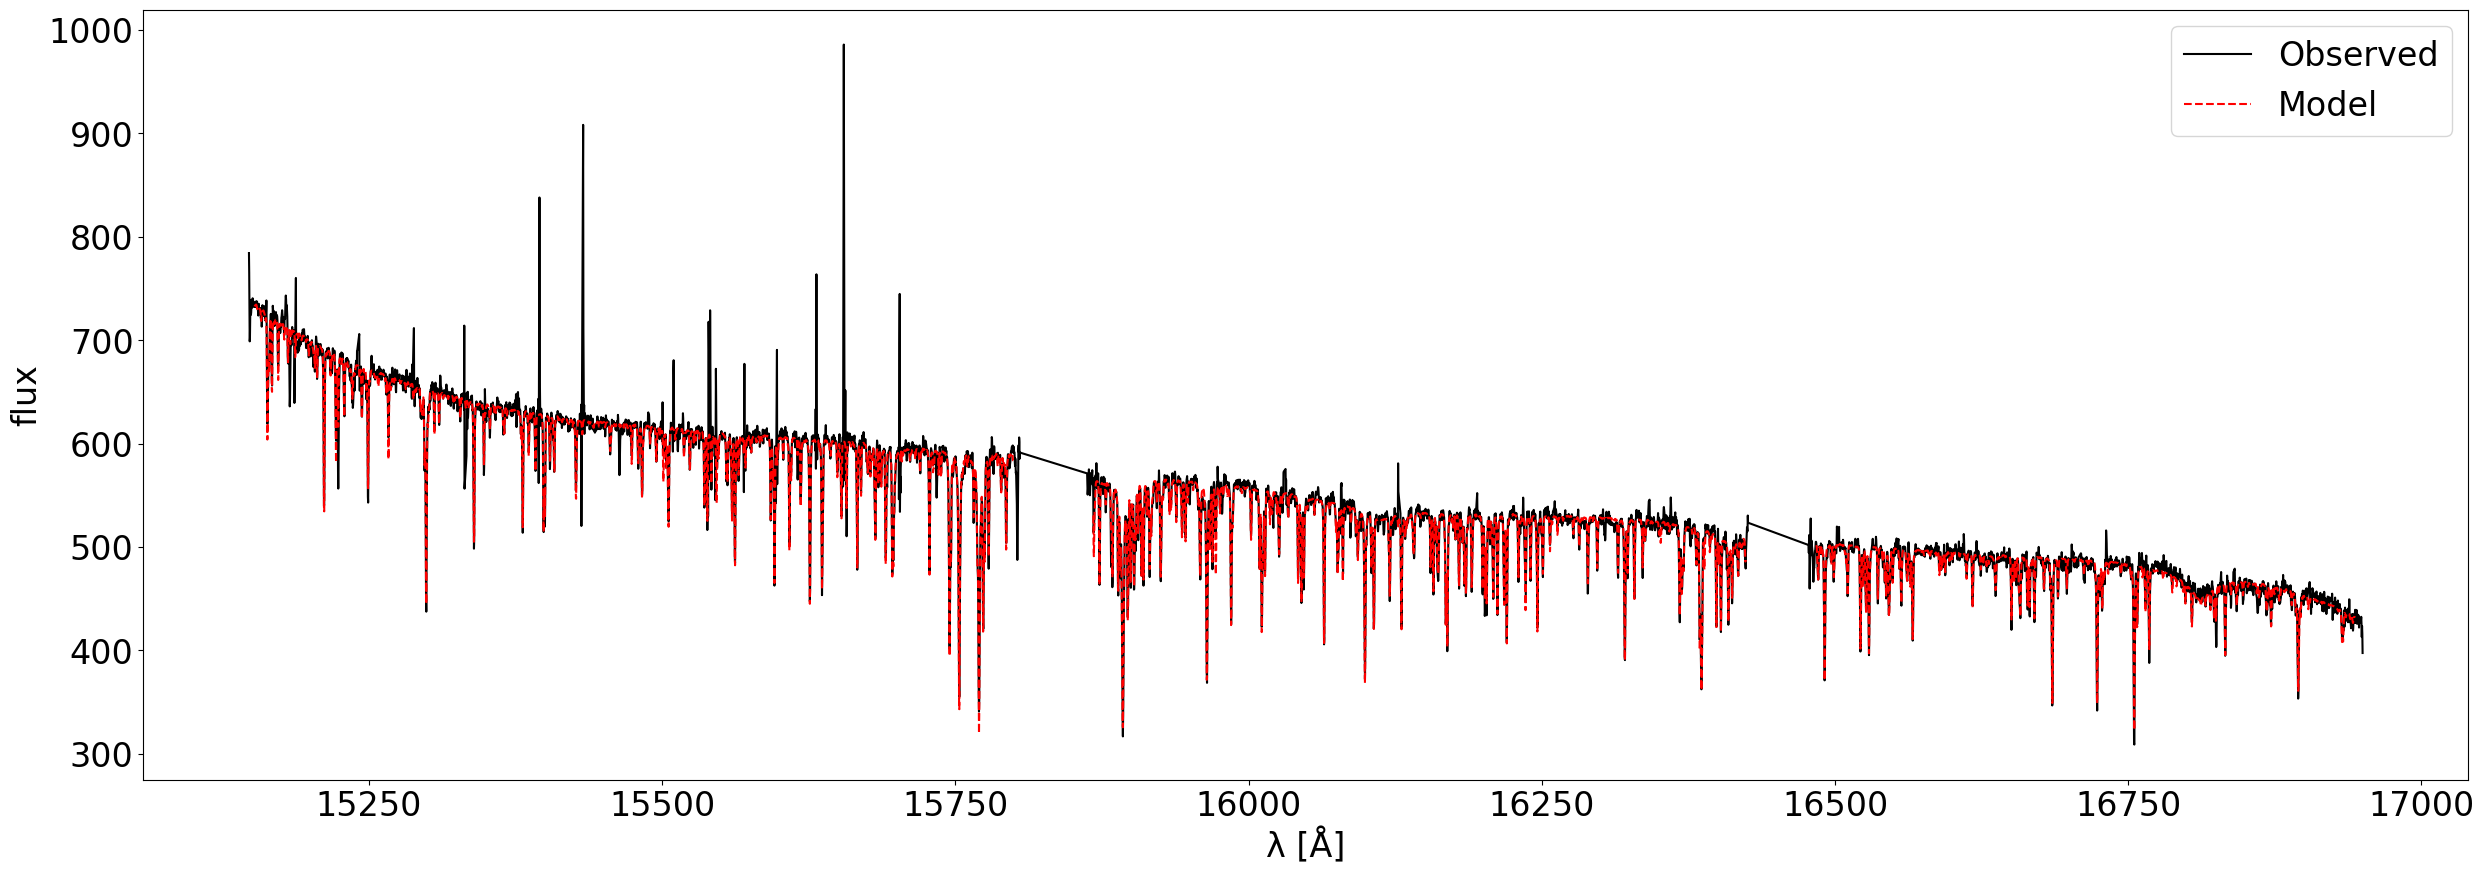

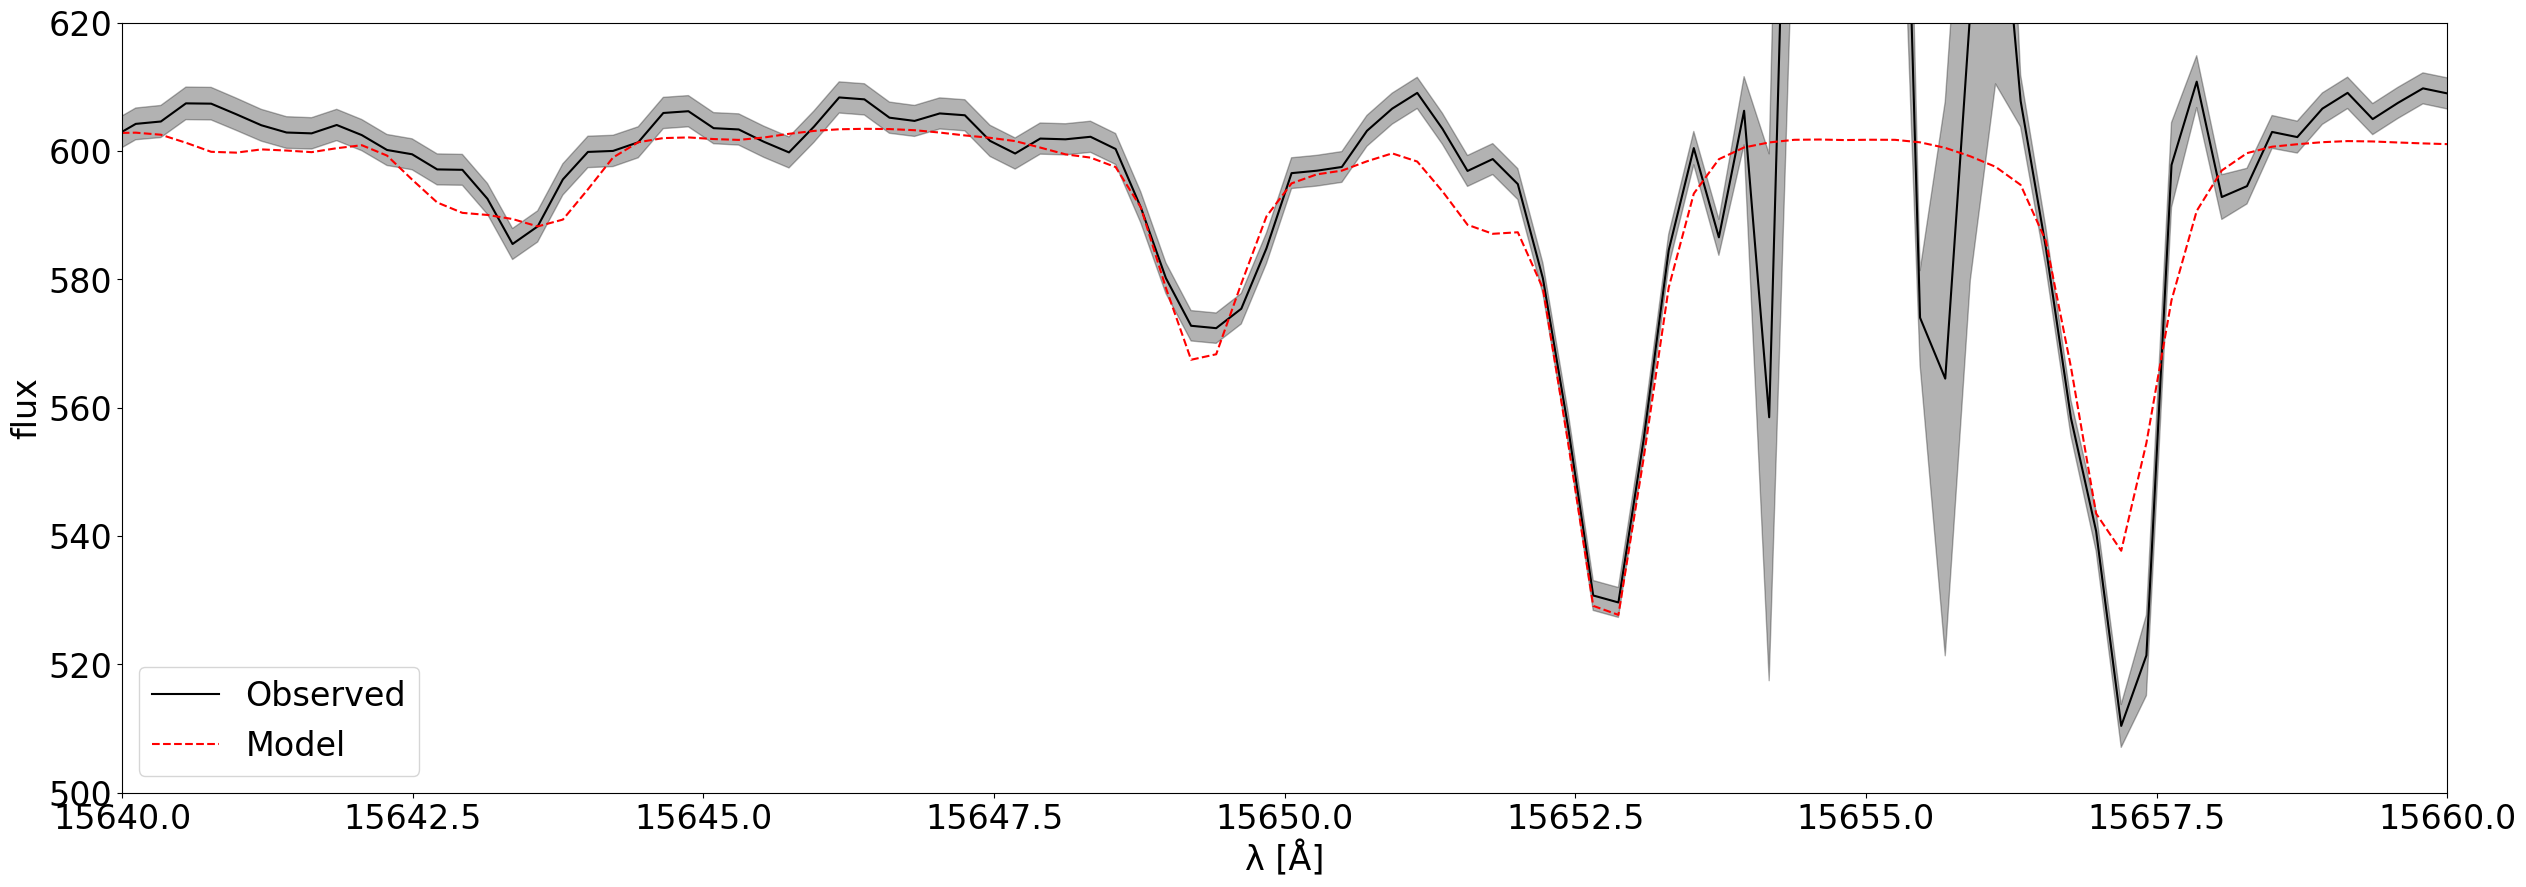

In [17]:
# observed data for plotting
obs_wl = mwmStar["wavelength"][0]
obs_flux = mwmStar["flux"][0]
obs_err = mwmStar["ivar"][0] ** (-0.5)

# model data for plotting
wavelength = aspcapStar["wavelength"][0]
model = aspcapStar["model_flux"][0]
continuum = aspcapStar["continuum"][0]

mask = obs_err < 0.1 * obs_flux

plt.figure(figsize=(30, 10))
plt.plot(obs_wl[mask], obs_flux[mask], c='k', label='Observed')
plt.plot(wavelength, model * continuum, linestyle="--", label="Model", c='r')
plt.xlabel("λ [Å]")
plt.ylabel("flux")
plt.legend()
plt.show()

plt.figure(figsize=(30, 10))
plt.plot(obs_wl[mask], obs_flux[mask], c='k', label='Observed')
plt.fill_between(obs_wl[mask], obs_flux[mask] - obs_err[mask], obs_flux[mask] + obs_err[mask], color='k', alpha=0.3)
plt.plot(wavelength, model * continuum, linestyle="--", label="Model", c='r')
plt.xlabel("λ [Å]")
plt.ylabel("flux")
plt.ylim(500, 620)
plt.xlim(15640, 15660)
plt.legend()
plt.show()